# **Approssimazione numerica di integrali**

## Formule di quadratura (approssimazione di integrali)

Le formule di quadratura sono tecniche numeriche volte ad approssimare integrali del tipo

$$\int_{a}^{b}f(s)ds$$

per mezzo di valutazioni *puntuali* dell'integranda $f$. In altre parole, una volta fissata un opportuna griglia $\{x_{0} < x_{1} < \dots < x_{n}\}\subset[a,b]$, l'idea è quella di combinare in maniera opportuna i valori $\{(x_{i}, f(x_{i}))\}$ per approssimare l'integrale in questione. Molto spesso, queste formule vengono costruire rimpiazzando $f$ con opportune interpolanti/approssimanti il cui integrale sia facile da calcolare.

In quanto segue, assumiamo di utilizzare una griglia uniforme di passo $h>0$.

In questo laboratorio ci occuperemo dell'approssimazione numerica di integrali tramite formule di quadratura composite.

### Metodo del punto medio (composito)

$$\int_{a}^{b}f(s)ds\approx \sum_{i=0}^{n-1}f\left(\frac{x_{i}+x_{i+1}}{2}\right)(x_{i+1}-x_{i})=h\sum_{i=0}^{n-1}f\left(x_{i}+\frac{h}{2}\right).$$

Geometricamente parlando, si sta approssimando l'area sottesa da $f$ con una serie di rettangoli (equivalentemente, stiamo sostituendo $f$ con una sua approssimazione **costante a tratti**).

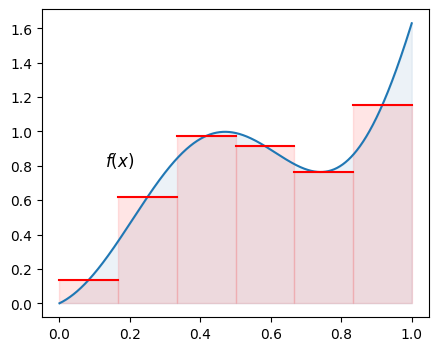

In [ ]:
from niceplots import show
show("Punto medio")

### Metodo dei trapezi (composito)

$$\int_{a}^{b}f(s)ds\approx \sum_{i=0}^{n-1}\frac{1}{2}\Big[f(x_{i})+f(x_{i+1})\Big](x_{i+1}-x_{i})=\frac{h}{2}\sum_{i=0}^{n-1}\Big[f(x_{i})+f(x_{i+1})\Big].$$

Geometricamente parlando, si sta approssimando l'area sottesa da $f$ con una serie di trapezi (equivalentemente, stiamo sostituendo $f$ con una sua approssimazione **lineare a tratti**).

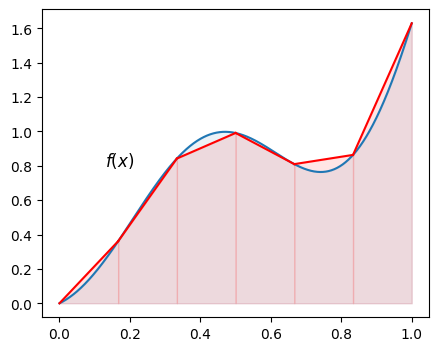

In [ ]:
show("Trapezi")

### Metodo di Cavalieri-Simpson (composito)

$$\int_{a}^{b}f(s)ds\approx \frac{h}{6}\sum_{i=0}^{n-1}\left[f(x_{i})+4f\left(\frac{x_{i}+x_{i+1}}{2}\right)+f(x_{i+1})\right].$$

Geometricamente parlando, si sta approssimando l'area sottesa da $f$ con una serie di "sotto parabole" (equivalentemente, stiamo sostituendo $f$ con una sua approssimazione **quadratica a tratti**).

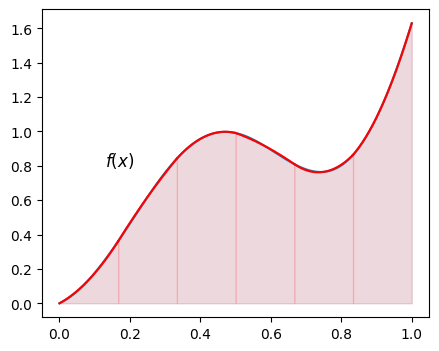

In [ ]:
show("Simpson")

# Esercizio 1

Si consideri il seguente integrale $I$:

\begin{equation}
I = \int_0^1 x^2 dx.
\end{equation}

Si vogliono confrontare le diverse formule di quadratura composite per il calcolo di $I$.

<mark>**Esercizio 1.1**</mark></br>
Scrivere tre funzioni, chiamate *pmedcomp*, *trapcomp* e *simpcomp*, che implementano rispettivamente le formule di quadratura composite del punto medio, del trapezio e di Simpson su intervalli equispaziati.
Tali funzioni dovranno ricevere in ingresso gli estremi di integrazione $a$ e $b$, il numero di sottointervalli $N$ in cui si vuole suddividere il dominio di integrazione, e la funzione $f$ da integrare; in uscita, dovranno restituire il valore approssimato dell'integrale.

In [ ]:
import numpy as np

In [ ]:
def pmedcomp(f, a, b, N):
    """
    Formula del punto medio composita.

    Approssima l'integrale definito ∫_a^b f(x)dx usando la formula composita
    del punto medio: l'intervallo [a,b] viene suddiviso in N sottointervalli,
    e in ogni sottointervallo l'integrale è approssimato col valore della
    funzione nel punto medio moltiplicato per la larghezza dell'intervallo.

    Input:
        f (callable): Funzione da integrare
        a (float): Estremo sinistro dell'intervallo di integrazione
        b (float): Estremo destro dell'intervallo di integrazione
        N (int): Numero di sottointervalli (N=1 per formula semplice)

    Output:
        I (float): Valore approssimato dell'integrale

    Nota:
        Accuratezza: O(h²) dove h = (b-a)/N
    """

    # Calcolo della larghezza di ogni sottointervallo
    h = (b - a) / N

    # Griglia spaziale nei nodi
    x = np.linspace(a, b, N + 1)

    # Nodi sinistri e destri di ogni sottointervallo
    xL, xR = x[:-1], x[1:]

    # Punti medi dei sottointervalli
    xM = 0.5 * (xL + xR)

    # Calcolo dell'integrale approssimato
    # I = ∑ f(x_i_medio) * h
    I = h * f(xM).sum()

    return I

In [ ]:
def trapcomp(f, a, b, N):
    """
    Formula dei trapezi composita.

    Approssima l'integrale definito ∫_a^b f(x)dx usando la formula composita
    dei trapezi: l'intervallo [a,b] viene suddiviso in N sottointervalli,
    e in ogni sottointervallo l'integrale è approssimato come l'area di un
    trapezio con altezza h e basi f(x_i) e f(x_{i+1}).

    Input:
        f (callable): Funzione da integrare
        a (float): Estremo sinistro dell'intervallo di integrazione
        b (float): Estremo destro dell'intervallo di integrazione
        N (int): Numero di sottointervalli (N=1 per formula semplice)

    Output:
        I (float): Valore approssimato dell'integrale

    Nota:
        Accuratezza: O(h²) dove h = (b-a)/N
    """

    # Calcolo della larghezza di ogni sottointervallo
    h = (b - a) / N

    # Griglia spaziale nei nodi
    x = np.linspace(a, b, N + 1)

    # Nodi sinistri e destri di ogni sottointervallo
    xL, xR = x[:-1], x[1:]

    # Calcolo dell'integrale approssimato
    # I = 0.5 * h * ∑ (f(x_i) + f(x_{i+1}))
    I = 0.5 * h * (f(xL) + f(xR)).sum()

    return I

In [ ]:
def simpcomp(f, a, b, N):
    """
    Formula di Cavalieri-Simpson composita.

    Approssima l'integrale definito ∫_a^b f(x)dx usando la formula composita
    di Simpson (parabole): l'intervallo [a,b] viene suddiviso in N sottointervalli,
    e in ogni sottointervallo l'integrale è approssimato usando un polinomio
    di grado 2 (parabola) passante per gli estremi e il punto medio.

    Input:
        f (callable): Funzione da integrare
        a (float): Estremo sinistro dell'intervallo di integrazione
        b (float): Estremo destro dell'intervallo di integrazione
        N (int): Numero di sottointervalli (N=1 per formula semplice)

    Output:
        I (float): Valore approssimato dell'integrale

    Nota:
        Accuratezza: O(h⁴) dove h = (b-a)/N
        È la formula più accurata tra quelle implementate per funzioni lisce.
    """

    # Calcolo della larghezza di ogni sottointervallo
    h = (b - a) / N

    # Griglia spaziale nei nodi
    x = np.linspace(a, b, N + 1)

    # Nodi sinistri e destri di ogni sottointervallo
    xL, xR = x[:-1], x[1:]

    # Punti medi dei sottointervalli
    xM = 0.5 * (xL + xR)

    # Calcolo dell'integrale approssimato usando la formula di Simpson
    # I = (h/6) * ∑ (f(x_i) + 4*f(x_i_medio) + f(x_{i+1}))
    I = (h / 6.0) * (f(xL) + 4 * f(xM) + f(xR)).sum()

    return I

<mark>**Esercizio 1.2**</mark></br>
Utilizzando le funzioni definite all'Esercizio 1.1, approssimare il valore dell'integrale $I$ usando $N=20$ sottointervalli. Calcolare quindi analiticamente (a mano) il vero valore dell'integrale e confrontarlo con le approssimazioni ottenute. Cosa si osserva? Commentare opportunamente il risultato ottenuto.

In [ ]:
# Definizione dell'integranda e dei parametri dell'esercizio
def f(x): return x**2


a, b = 0, 1
N = 20

# Integrali approssimati
I_pmc = pmedcomp(f, a, b, N)
I_tc = trapcomp(f, a, b, N)
I_sc = simpcomp(f, a, b, N)

# Integrale esatto
I_ex = 1/3

# Calcolo degli errori
err_pmc = abs(I_ex - I_pmc)
err_tc = abs(I_ex - I_tc)
err_sc = abs(I_ex - I_sc)

print("Errori assoluti\n"+"-"*28)
print("Punto medio\t%e" % err_pmc)
print("Trapezi\t\t%e" % err_tc)
print("Simpson\t\t%e" % err_sc)

Errori assoluti
----------------------------
Punto medio	2.083333e-04
Trapezi		4.166667e-04
Simpson		0.000000e+00


<mark>**Domanda**</mark></br>
Quale è il grado di esattezza delle formule di quadratura implementate? I risultati ottenuti confermano quello che sappiamo dalla teoria?

Si ricordano di seguito le stime dell'errore commesso dalle tre formule di quadratura implementate:

\begin{equation}
E_{PM}^c \le \frac{b-a}{24} \cdot h^2 \cdot ||f^{(ii)}||_\infty
\end{equation}
\begin{equation}
E_{T}^c \le \frac{b-a}{12} \cdot h^2 \cdot ||f^{(ii)}||_\infty
\end{equation}
\begin{equation}
E_{CS}^c \le \frac{b-a}{16\cdot180} \cdot h^4 \cdot ||f^{(iv)}||_\infty
\end{equation}

# Esercizio 2

Si consideri il seguente integrale,

$$ I = \int_0^1 x^5\sin(\pi x)dx,$$

il cui valore esatto è $(120-20\pi^2+\pi^4)/\pi^5.$

<mark>**Esercizio 2.1**</mark></br>

Si calcolino gli errori associati alle tre formule di quadratura (punto medio, trapezi, Cavalieri-Simpson) per il calcolo dell'integrale $I$, all'aumentare del numero di sottointervalli: $N=5, 10, 20, 40, 80$ ($N=5\cdot2^k, k=0,...,4$), o in altre parole, al dimezzarsi dell'ampiezza $h$ dei sottointervalli. Si verifichino poi gli ordini di convergenza previsti dalla teoria per le tre formule di quadratura rappresentando gli errori in un grafico opportuno. Si commentino i risultati.

Si ricordano di nuovo le stime dell'errore commesso dalle tre formule di quadratura implementate:

\begin{equation}
\begin{aligned}
E_{PM}^c &\le \frac{b-a}{24} \cdot h^2 \cdot ||f^{(ii)}||_\infty \simeq Ch^2 \\
E_{T}^c &\le \frac{b-a}{12} \cdot h^2 \cdot ||f^{(ii)}||_\infty \simeq Ch^2\\
E_{CS}^c &\le \frac{b-a}{16\cdot180} \cdot h^4 \cdot ||f^{(iv)}||_\infty \simeq Ch^4
\end{aligned}
\end{equation}

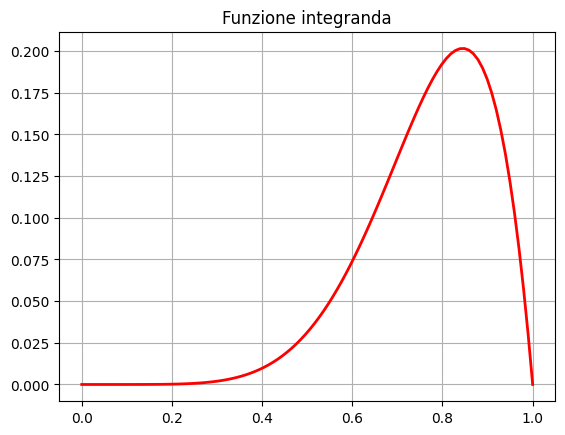

In [ ]:
import matplotlib.pyplot as plt
from numpy import pi, sin

# Definisco l'integranda e i parametri dell'esercizio


def f(x): return (x**5)*sin(pi*x)


a, b = 0, 1

# Rappresento la funzione
x_grid = np.linspace(a, b, 100)

plt.figure()
plt.plot(x_grid, f(x_grid), 'r', linewidth=2)
plt.title("Funzione integranda")
plt.grid()
plt.show()

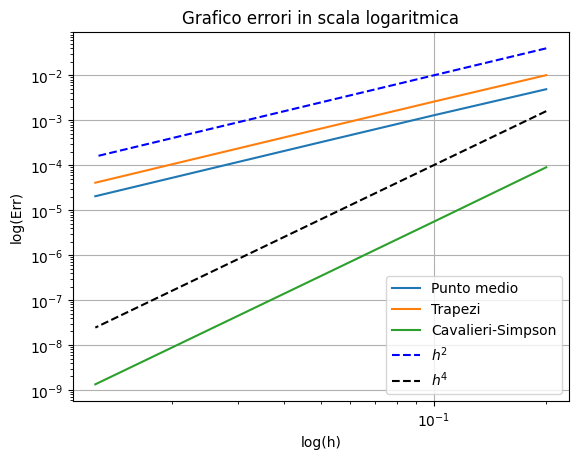

In [ ]:
# Valore esatto dell'integrale
I_ex = (120-20*pi**2 + pi**4)/(pi**5)

# Inizializzo un "dizionario" per gestire gli errori -> si veda sotto l'Approfondimento
err = {'Punto medio': [], 'Trapezi': [], 'Cavalieri-Simpson': []}

# Calcolo gli errori al variare del numero di suddivisioni dell'intervallo
N_vect = [5, 10, 20, 40, 80]

for N in N_vect:
    I1 = pmedcomp(f, a, b, N)
    err['Punto medio'].append(abs(I1 - I_ex))
    I2 = trapcomp(f, a, b, N)
    err['Trapezi'].append(abs(I2 - I_ex))
    I3 = simpcomp(f, a, b, N)
    err['Cavalieri-Simpson'].append(abs(I3 - I_ex))

# Calcolo la distanza h tra i nodi di approssimazione
h_vect = (b-a)/np.array(N_vect)

# Verifico l'ordine di convergenza -> grafico LOGLOG!
plt.figure()

# Il ciclo for sottostante è equivalente a fare
# plt.loglog(h, errori['Punto medio'], label = 'Punto medio')
# plt.loglog(h, errori['Trapezi'], label = 'Trapezi')
# plt.loglog(h, errori['Cavalieri-Simpson'], label = 'Cavalieri-Simpson')
for metodo in err.keys():
    plt.loglog(h_vect, err[metodo], label=metodo)

plt.loglog(h_vect, h_vect**2, '--b', label='$h^2$')
plt.loglog(h_vect, h_vect**4, '--k', label='$h^4$')
plt.title('Grafico errori in scala logaritmica')
plt.legend()
plt.grid()
plt.xlabel("log(h)")
plt.ylabel("log(Err)")
plt.show()

<mark>**Domanda**</mark></br>
Quale è l'ordine di accuratezza delle formule di quadratura implementate? I risultati ottenuti confermano quello che sappiamo dalla teoria? Perchè la scelta migliore è quella di utilizzare un grafico loglog per rappresentare l'errore?

**Commento**

Osserviamo che i metodi del Punto medio e dei Trapezi sono di ordine 2. Invece, il metodo di Cavalieri-Simpson è di ordine 4. L'ordine di accuratezza è in perfetto accordo con le stime teoriche.

# Approfondimento: i dizionari in python

La soluzione proposta fa uso dei cosìdetti *dizionari*, oggetti simili alle liste ma che si distinguono per l'utilizzo di etichette (dette *chiavi*), al posto dei classici indici posizionali. Ovviamente, non è necessario utilizzare i dizionari per risolvere l'esercizio, si tratta solo di una piccola aggiunta volta ad espandere la vostra conoscenza del linguaggio.

La chiamata

    carrello = {'banane':5, 'mele':4, 'pere':8}

definisce un dizionario, le cui *chiavi* sono le stringhe 'banane', 'mele' e 'pere'. Queste etichette, si possono utilizzare per accedere agli elementi corrispondenti. Per esempio,

    carrello['banane']

restituisce 5, che è il valore corrispondente. In generale, il contenuto di un dizionario può essere qualsiasi: qui, gli elementi sono numeri interi, nell'esercizio, invece, gli elementi sono liste (liste di errori, una per ogni metodo).

L'elenco delle chiavi in un dizionario si può estrarre con il metodo ".keys()"

    carrello.keys()

che qui restituisce un iterabile (sostanzialmente una lista) contenente 'banane', 'mele' e 'pere'.